In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

BASE_PATH = "/content/drive/MyDrive/Coding/FCSO Image Identification"

INPUT_PATH = os.path.join(BASE_PATH, "Input")
TEST_PATH = os.path.join(BASE_PATH, "Test Set")
OUTPUT_PATH = os.path.join(BASE_PATH, "Output")

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Input Folder Exists:", os.path.exists(INPUT_PATH))
print("Test Folder Exists:", os.path.exists(TEST_PATH))
print("Output Folder Exists:", os.path.exists(OUTPUT_PATH))

print("\nInput Files:")
print(os.listdir(INPUT_PATH))

print("\nTest Files:")
print(os.listdir(TEST_PATH))

Input Folder Exists: True
Test Folder Exists: True
Output Folder Exists: True

Input Files:
['Input_Yee Jenn Jong.jpeg']

Test Files:
['Target_1.1.jpeg', 'Target_1.2.jpeg', 'Target_1.3.jpeg', 'Target_1.4.jpeg', 'Target_2.1.jpeg', 'Target_3.1.jpeg', 'Target_4.1.jpeg', 'Target_5.1.jpeg', 'Target_6.1.jpeg', 'Target_7.1.jpeg', 'Target_8.1.jpeg', 'Target_10.1.jpeg', 'Target_11.1.jpeg', 'Target_12.1.jpeg', 'Target_13.1.jpeg', 'Target_1.5.jpeg', 'Targte_1.6.jpeg', 'Target_1.7.jpeg', 'Target_1.8.jpeg', 'Target_1.9.jpeg', 'Target_14.1.jpeg', 'Target_16.1.jpeg', 'Targte_17.1.jpeg', 'Target_18.1.jpeg', 'Target_19.1.jpeg', 'Target_20.1.jpeg', 'Target_21.1.jpeg', 'Target_22.1.jpeg', 'Target_1.2_Grey.jpg']


In [3]:
!pip install -q insightface onnxruntime-gpu
!pip install -q opencv-python-headless

In [4]:
import onnxruntime as ort

print("Available Providers:")
print(ort.get_available_providers())

Available Providers:
['AzureExecutionProvider', 'CPUExecutionProvider']


In [5]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"]
)

app.prepare(ctx_id=-1, det_size=(640, 640))

print("InsightFace model loaded successfully")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
InsightFace 

In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
def calculate_blur_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def calculate_brightness(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return gray.mean()


def cosine_similarity(vec1, vec2):
    vec1 = vec1 / np.linalg.norm(vec1)
    vec2 = vec2 / np.linalg.norm(vec2)
    return float(np.dot(vec1, vec2))


def similarity_label(score):
    if score is None:
        return "No Comparison"
    if score >= 0.70:
        return "Very High Similarity"
    elif score >= 0.50:
        return "Possible Similarity"
    elif score >= 0.30:
        return "Weak Similarity"
    else:
        return "Low Similarity"


def map_gender_label(gender_raw):
    """
    InsightFace commonly returns:
    0 = Female
    1 = Male

    Treat this only as model-estimated metadata.
    """
    if gender_raw is None:
        return None
    elif gender_raw == 0:
        return "Female_estimated"
    elif gender_raw == 1:
        return "Male_estimated"
    else:
        return f"Unknown_{gender_raw}"


print("Helper functions loaded")

Helper functions loaded


In [8]:
probe_files = [
    f for f in os.listdir(INPUT_PATH)
    if not f.startswith(".")
]

print("Probe files found:", probe_files)

if len(probe_files) == 0:
    raise ValueError("No probe image found in Input folder")

probe_image_path = os.path.join(INPUT_PATH, probe_files[0])

print("Using probe image:")
print(probe_image_path)

Probe files found: ['Input_Yee Jenn Jong.jpeg']
Using probe image:
/content/drive/MyDrive/Coding/FCSO Image Identification/Input/Input_Yee Jenn Jong.jpeg


In [9]:
def extract_probe_face_info(image_path, app):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("Probe image could not be read")

    faces = app.get(image)

    blur_score = calculate_blur_score(image)
    brightness = calculate_brightness(image)

    if len(faces) == 0:
        raise ValueError("No face detected in probe image. Please use a clearer probe image.")

    if len(faces) > 1:
        print("WARNING: Multiple faces detected in probe image. Using the largest face.")
        print("For best results, crop the probe image to one face.")

    # For probe only, choose largest face if more than one exists
    def face_area(face):
        x1, y1, x2, y2 = face.bbox
        return (x2 - x1) * (y2 - y1)

    selected_face = max(faces, key=face_area)

    bbox = selected_face.bbox.astype(int)
    x1, y1, x2, y2 = bbox

    face_width = int(x2 - x1)
    face_height = int(y2 - y1)

    gender_raw = getattr(selected_face, "gender", None)
    age_estimated = getattr(selected_face, "age", None)

    result = {
        "image_path": image_path,
        "file_name": os.path.basename(image_path),
        "num_faces": len(faces),
        "det_score": float(selected_face.det_score),
        "bbox": bbox.tolist(),
        "face_width": face_width,
        "face_height": face_height,
        "blur_score": float(blur_score),
        "brightness": float(brightness),
        "gender_raw": gender_raw,
        "gender_label": map_gender_label(gender_raw),
        "age_estimated": age_estimated,
        "embedding": selected_face.embedding
    }

    return result

In [10]:
probe_result = extract_probe_face_info(probe_image_path, app)

probe_display = probe_result.copy()
probe_display.pop("embedding", None)

print("Probe Image Analysis:")
for k, v in probe_display.items():
    print(f"{k}: {v}")

Probe Image Analysis:
image_path: /content/drive/MyDrive/Coding/FCSO Image Identification/Input/Input_Yee Jenn Jong.jpeg
file_name: Input_Yee Jenn Jong.jpeg
num_faces: 1
det_score: 0.8814139366149902
bbox: [53, 38, 136, 155]
face_width: 83
face_height: 117
blur_score: 1062.3317204045507
brightness: 179.61359719498427
gender_raw: 1
gender_label: Male_estimated
age_estimated: 45


In [11]:
def draw_bbox(image_path, bbox, label=None):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if bbox is not None:
        x1, y1, x2, y2 = [int(v) for v in bbox]
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)

        if label:
            cv2.putText(
                image_rgb,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 0, 0),
                2
            )

    return image_rgb

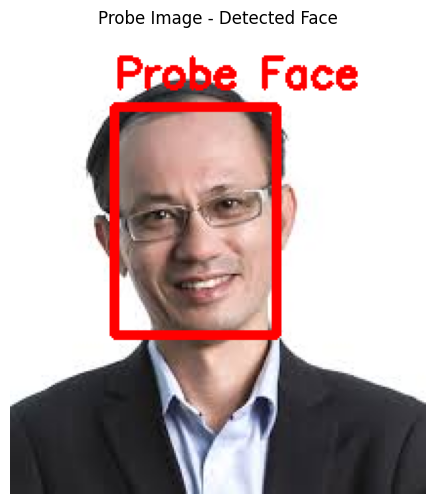

In [12]:
probe_box_img = draw_bbox(probe_image_path, probe_result["bbox"], "Probe Face")

plt.figure(figsize=(6, 6))
plt.imshow(probe_box_img)
plt.axis("off")
plt.title("Probe Image - Detected Face")
plt.show()

In [13]:
def extract_all_target_faces_info(image_path, app):
    image = cv2.imread(image_path)

    if image is None:
        return [{
            "image_path": image_path,
            "file_name": os.path.basename(image_path),
            "status": "FAIL",
            "notes": "Image could not be read",
            "num_faces_in_image": 0,
            "face_index": None,
            "det_score": None,
            "bbox": None,
            "face_width": None,
            "face_height": None,
            "blur_score": None,
            "brightness": None,
            "gender_raw": None,
            "gender_label": None,
            "age_estimated": None,
            "embedding": None
        }]

    faces = app.get(image)

    blur_score = calculate_blur_score(image)
    brightness = calculate_brightness(image)

    if len(faces) == 0:
        return [{
            "image_path": image_path,
            "file_name": os.path.basename(image_path),
            "status": "FAIL",
            "notes": "No face detected",
            "num_faces_in_image": 0,
            "face_index": None,
            "det_score": None,
            "bbox": None,
            "face_width": None,
            "face_height": None,
            "blur_score": float(blur_score),
            "brightness": float(brightness),
            "gender_raw": None,
            "gender_label": None,
            "age_estimated": None,
            "embedding": None
        }]

    face_records = []

    for face_index, face in enumerate(faces):
        bbox = face.bbox.astype(int)
        x1, y1, x2, y2 = bbox

        face_width = int(x2 - x1)
        face_height = int(y2 - y1)

        notes = []

        if len(faces) > 1:
            notes.append("Multiple faces in image; this row is one detected face")

        if face.det_score < 0.70:
            notes.append("Low face detection confidence")

        if face_width < 80 or face_height < 80:
            notes.append("Small face size")

        if blur_score < 50:
            notes.append("Image may be blurry")

        if brightness < 40:
            notes.append("Image may be too dark")

        if brightness > 220:
            notes.append("Image may be too bright")

        status = "PASS" if len(notes) == 0 else "WARNING"

        gender_raw = getattr(face, "gender", None)
        age_estimated = getattr(face, "age", None)

        face_records.append({
            "image_path": image_path,
            "file_name": os.path.basename(image_path),
            "status": status,
            "notes": "; ".join(notes) if notes else "Good quality face",
            "num_faces_in_image": len(faces),
            "face_index": face_index,
            "det_score": float(face.det_score),
            "bbox": bbox.tolist(),
            "face_width": face_width,
            "face_height": face_height,
            "blur_score": float(blur_score),
            "brightness": float(brightness),
            "gender_raw": gender_raw,
            "gender_label": map_gender_label(gender_raw),
            "age_estimated": age_estimated,
            "embedding": face.embedding
        })

    return face_records

In [14]:
target_files = [
    f for f in os.listdir(TEST_PATH)
    if not f.startswith(".")
]

print("Target files found:", len(target_files))

for f in target_files:
    print(f)

Target files found: 29
Target_1.1.jpeg
Target_1.2.jpeg
Target_1.3.jpeg
Target_1.4.jpeg
Target_2.1.jpeg
Target_3.1.jpeg
Target_4.1.jpeg
Target_5.1.jpeg
Target_6.1.jpeg
Target_7.1.jpeg
Target_8.1.jpeg
Target_10.1.jpeg
Target_11.1.jpeg
Target_12.1.jpeg
Target_13.1.jpeg
Target_1.5.jpeg
Targte_1.6.jpeg
Target_1.7.jpeg
Target_1.8.jpeg
Target_1.9.jpeg
Target_14.1.jpeg
Target_16.1.jpeg
Targte_17.1.jpeg
Target_18.1.jpeg
Target_19.1.jpeg
Target_20.1.jpeg
Target_21.1.jpeg
Target_22.1.jpeg
Target_1.2_Grey.jpg


In [15]:
target_face_records = []

for file_name in target_files:
    image_path = os.path.join(TEST_PATH, file_name)
    records = extract_all_target_faces_info(image_path, app)
    target_face_records.extend(records)

print("Total target images:", len(target_files))
print("Total face-level records:", len(target_face_records))

Total target images: 29
Total face-level records: 88


In [16]:
face_quality_rows = []

for r in target_face_records:
    row = r.copy()
    row.pop("embedding", None)
    face_quality_rows.append(row)

face_quality_df = pd.DataFrame(face_quality_rows)

face_quality_df[[
    "file_name",
    "face_index",
    "num_faces_in_image",
    "status",
    "notes",
    "det_score",
    "face_width",
    "face_height",
    "blur_score",
    "brightness",
    "gender_label",
    "age_estimated",
    "bbox"
]]

,file_name,face_index,num_faces_in_image,status,notes,det_score,face_width,face_height,blur_score,brightness,gender_label,age_estimated,bbox
0,Target_1.1.jpeg,0.0,1,WARNING,Small face size,0.788408,48.0,63.0,1481.764914,101.329419,Male_estimated,58.0,"[73, 42, 121, 105]"
1,Target_1.2.jpeg,0.0,1,WARNING,Low face detection confidence,0.657245,94.0,143.0,461.243175,95.165025,Male_estimated,52.0,"[40, 31, 134, 174]"
2,Target_1.3.jpeg,0.0,4,WARNING,Multiple faces in image; this row is one detec...,0.885389,46.0,65.0,1921.668031,181.415654,Male_estimated,49.0,"[246, 28, 292, 93]"
3,Target_1.3.jpeg,1.0,4,WARNING,Multiple faces in image; this row is one detec...,0.876754,51.0,65.0,1921.668031,181.415654,Male_estimated,31.0,"[89, 31, 140, 96]"
4,Target_1.3.jpeg,2.0,4,WARNING,Multiple faces in image; this row is one detec...,0.856697,51.0,67.0,1921.668031,181.415654,Male_estimated,30.0,"[172, 27, 223, 94]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,Target_21.1.jpeg,3.0,4,WARNING,Multiple faces in image; this row is one detec...,0.782597,49.0,75.0,2388.461613,107.652114,Male_estimated,55.0,"[159, 24, 208, 99]"
84,Target_22.1.jpeg,0.0,3,WARNING,Multiple faces in image; this row is one detec...,0.876191,25.0,30.0,4288.822054,94.704734,Male_estimated,29.0,"[44, 86, 69, 116]"
85,Target_22.1.jpeg,1.0,3,WARNING,Multiple faces in image; this row is one detec...,0.866096,29.0,36.0,4288.822054,94.704734,Male_estimated,58.0,"[185, 28, 214, 64]"
86,Target_22.1.jpeg,2.0,3,WARNING,Multiple faces in image; this row is one detec...,0.862477,23.0,33.0,4288.822054,94.704734,Male_estimated,61.0,"[118, 9, 141, 42]"


In [17]:
print("Status Summary:")
print(face_quality_df["status"].value_counts(dropna=False))

print("\nFaces per image:")
print(face_quality_df.groupby("file_name")["face_index"].count().sort_values(ascending=False))

Status Summary:
status
WARNING    83
PASS        4
FAIL        1
Name: count, dtype: int64

Faces per image:
file_name
Target_6.1.jpeg        15
Target_14.1.jpeg       10
Target_8.1.jpeg        10
Target_19.1.jpeg        7
Target_20.1.jpeg        6
Target_5.1.jpeg         4
Target_21.1.jpeg        4
Target_1.3.jpeg         4
Target_22.1.jpeg        3
Target_7.1.jpeg         3
Target_1.8.jpeg         2
Target_1.7.jpeg         2
Target_11.1.jpeg        2
Target_13.1.jpeg        1
Target_12.1.jpeg        1
Target_10.1.jpeg        1
Target_1.9.jpeg         1
Target_1.5.jpeg         1
Target_1.2.jpeg         1
Target_1.2_Grey.jpg     1
Target_1.4.jpeg         1
Target_1.1.jpeg         1
Target_2.1.jpeg         1
Target_16.1.jpeg        1
Target_18.1.jpeg        1
Target_3.1.jpeg         1
Target_4.1.jpeg         1
Targte_17.1.jpeg        1
Targte_1.6.jpeg         0
Name: face_index, dtype: int64


In [18]:
face_similarity_results = []

probe_embedding = probe_result["embedding"]

for r in target_face_records:
    row = r.copy()
    embedding = row.pop("embedding", None)

    if embedding is not None:
        row["similarity_score"] = cosine_similarity(probe_embedding, embedding)
    else:
        row["similarity_score"] = None

    face_similarity_results.append(row)

face_ranked_df = pd.DataFrame(face_similarity_results)

face_ranked_df = face_ranked_df.sort_values(
    by="similarity_score",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

face_ranked_df["rank"] = face_ranked_df.index + 1
face_ranked_df["similarity_label"] = face_ranked_df["similarity_score"].apply(similarity_label)

face_ranked_df[[
    "rank",
    "file_name",
    "face_index",
    "similarity_score",
    "similarity_label",
    "status",
    "notes",
    "num_faces_in_image",
    "det_score",
    "face_width",
    "face_height",
    "gender_label",
    "age_estimated",
    "bbox"
]].head(25)

,rank,file_name,face_index,similarity_score,similarity_label,status,notes,num_faces_in_image,det_score,face_width,face_height,gender_label,age_estimated,bbox
0,1,Target_1.2.jpeg,0.0,0.750281,Very High Similarity,WARNING,Low face detection confidence,1,0.657245,94.0,143.0,Male_estimated,52.0,"[40, 31, 134, 174]"
1,2,Target_1.5.jpeg,0.0,0.746538,Very High Similarity,WARNING,Small face size,1,0.778038,48.0,72.0,Male_estimated,50.0,"[66, 34, 114, 106]"
2,3,Target_1.2_Grey.jpg,0.0,0.738309,Very High Similarity,WARNING,Low face detection confidence,1,0.694150,96.0,144.0,Male_estimated,73.0,"[40, 31, 136, 175]"
3,4,Target_1.3.jpeg,0.0,0.725258,Very High Similarity,WARNING,Multiple faces in image; this row is one detec...,4,0.885389,46.0,65.0,Male_estimated,49.0,"[246, 28, 292, 93]"
4,5,Target_1.4.jpeg,0.0,0.655330,Possible Similarity,WARNING,Small face size,1,0.816855,74.0,107.0,Male_estimated,59.0,"[115, 24, 189, 131]"
5,6,Target_1.1.jpeg,0.0,0.630721,Possible Similarity,WARNING,Small face size,1,0.788408,48.0,63.0,Male_estimated,58.0,"[73, 42, 121, 105]"
6,7,Target_1.9.jpeg,0.0,0.350419,Weak Similarity,WARNING,Small face size,1,0.724613,12.0,16.0,Male_estimated,46.0,"[165, 175, 177, 191]"
7,8,Target_14.1.jpeg,4.0,0.183750,Low Similarity,WARNING,Multiple faces in image; this row is one detec...,10,0.833130,43.0,54.0,Male_estimated,56.0,"[65, 13, 108, 67]"
8,9,Target_8.1.jpeg,0.0,0.122047,Low Similarity,WARNING,Multiple faces in image; this row is one detec...,10,0.879139,24.0,27.0,Male_estimated,38.0,"[36, 62, 60, 89]"
9,10,Target_18.1.jpeg,0.0,0.116714,Low Similarity,PASS,Good quality face,1,0.828979,112.0,152.0,Male_estimated,34.0,"[40, 43, 152, 195]"


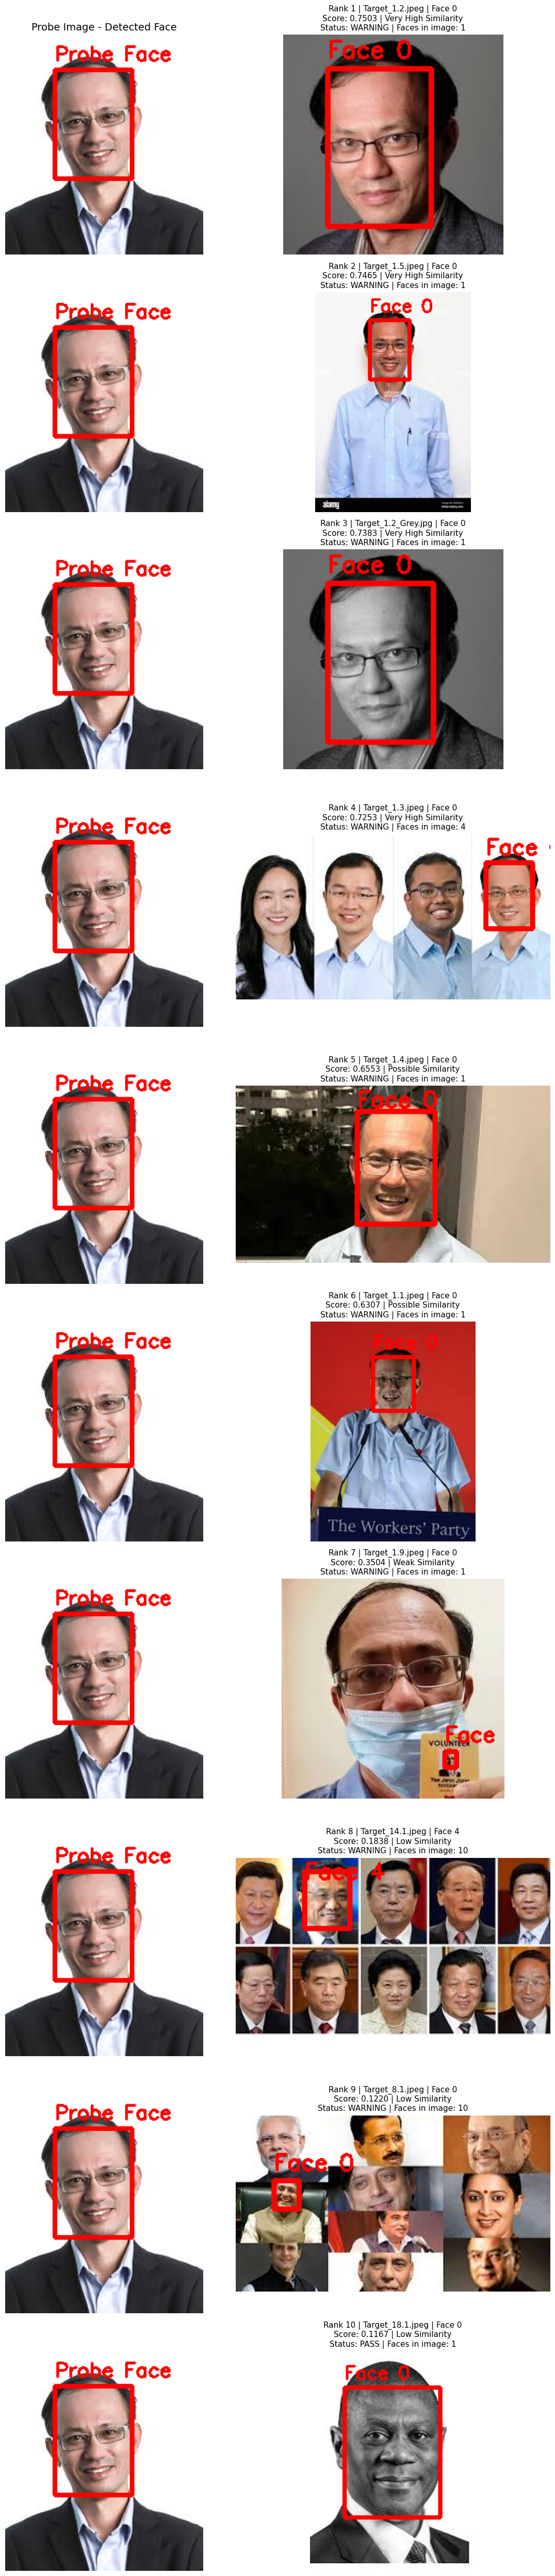

In [19]:
TOP_K = 10

top_matches = face_ranked_df.head(TOP_K)

probe_box_img = draw_bbox(probe_image_path, probe_result["bbox"], "Probe Face")

fig, axes = plt.subplots(TOP_K, 2, figsize=(12, 5 * TOP_K))

if TOP_K == 1:
    axes = np.array([axes])

for idx, (_, row) in enumerate(top_matches.iterrows()):

    axes[idx, 0].imshow(probe_box_img)
    axes[idx, 0].axis("off")

    if idx == 0:
        axes[idx, 0].set_title("Probe Image - Detected Face", fontsize=14)

    target_path = os.path.join(TEST_PATH, row["file_name"])

    label = f'Face {int(row["face_index"])}'
    target_box_img = draw_bbox(target_path, row["bbox"], label)

    axes[idx, 1].imshow(target_box_img)
    axes[idx, 1].axis("off")

    axes[idx, 1].set_title(
        f'Rank {int(row["rank"])} | {row["file_name"]} | Face {int(row["face_index"])}\n'
        f'Score: {row["similarity_score"]:.4f} | {row["similarity_label"]}\n'
        f'Status: {row["status"]} | Faces in image: {int(row["num_faces_in_image"])}',
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [20]:
export_cols = [
    "rank",
    "file_name",
    "face_index",
    "similarity_score",
    "similarity_label",
    "status",
    "notes",
    "num_faces_in_image",
    "det_score",
    "face_width",
    "face_height",
    "blur_score",
    "brightness",
    "gender_label",
    "age_estimated",
    "bbox",
    "image_path"
]

export_df = face_ranked_df[export_cols].copy()

numeric_cols = [
    "similarity_score",
    "det_score",
    "blur_score",
    "brightness"
]

for col in numeric_cols:
    export_df[col] = export_df[col].round(4)

output_csv_path = os.path.join(OUTPUT_PATH, "face_level_ranked_similarity_results.csv")

export_df.to_csv(output_csv_path, index=False)

print("Face-level CSV report saved at:")
print(output_csv_path)

export_df.head(20)

Face-level CSV report saved at:
/content/drive/MyDrive/Coding/FCSO Image Identification/Output/face_level_ranked_similarity_results.csv


,rank,file_name,face_index,similarity_score,similarity_label,status,notes,num_faces_in_image,det_score,face_width,face_height,blur_score,brightness,gender_label,age_estimated,bbox,image_path
0,1,Target_1.2.jpeg,0.0,0.7503,Very High Similarity,WARNING,Low face detection confidence,1,0.6572,94.0,143.0,461.2432,95.1650,Male_estimated,52.0,"[40, 31, 134, 174]",/content/drive/MyDrive/Coding/FCSO Image Ident...
1,2,Target_1.5.jpeg,0.0,0.7465,Very High Similarity,WARNING,Small face size,1,0.7780,48.0,72.0,1053.6671,199.5650,Male_estimated,50.0,"[66, 34, 114, 106]",/content/drive/MyDrive/Coding/FCSO Image Ident...
2,3,Target_1.2_Grey.jpg,0.0,0.7383,Very High Similarity,WARNING,Low face detection confidence,1,0.6942,96.0,144.0,440.4651,94.6729,Male_estimated,73.0,"[40, 31, 136, 175]",/content/drive/MyDrive/Coding/FCSO Image Ident...
3,4,Target_1.3.jpeg,0.0,0.7253,Very High Similarity,WARNING,Multiple faces in image; this row is one detec...,4,0.8854,46.0,65.0,1921.6680,181.4157,Male_estimated,49.0,"[246, 28, 292, 93]",/content/drive/MyDrive/Coding/FCSO Image Ident...
4,5,Target_1.4.jpeg,0.0,0.6553,Possible Similarity,WARNING,Small face size,1,0.8169,74.0,107.0,1300.3581,107.7510,Male_estimated,59.0,"[115, 24, 189, 131]",/content/drive/MyDrive/Coding/FCSO Image Ident...
5,6,Target_1.1.jpeg,0.0,0.6307,Possible Similarity,WARNING,Small face size,1,0.7884,48.0,63.0,1481.7649,101.3294,Male_estimated,58.0,"[73, 42, 121, 105]",/content/drive/MyDrive/Coding/FCSO Image Ident...
6,7,Target_1.9.jpeg,0.0,0.3504,Weak Similarity,WARNING,Small face size,1,0.7246,12.0,16.0,1557.2041,165.0213,Male_estimated,46.0,"[165, 175, 177, 191]",/content/drive/MyDrive/Coding/FCSO Image Ident...
7,8,Target_14.1.jpeg,4.0,0.1838,Low Similarity,WARNING,Multiple faces in image; this row is one detec...,10,0.8331,43.0,54.0,4675.3524,108.3312,Male_estimated,56.0,"[65, 13, 108, 67]",/content/drive/MyDrive/Coding/FCSO Image Ident...
8,9,Target_8.1.jpeg,0.0,0.1220,Low Similarity,WARNING,Multiple faces in image; this row is one detec...,10,0.8791,24.0,27.0,2250.3330,132.4472,Male_estimated,38.0,"[36, 62, 60, 89]",/content/drive/MyDrive/Coding/FCSO Image Ident...
9,10,Target_18.1.jpeg,0.0,0.1167,Low Similarity,PASS,Good quality face,1,0.8290,112.0,152.0,1639.8650,170.8385,Male_estimated,34.0,"[40, 43, 152, 195]",/content/drive/MyDrive/Coding/FCSO Image Ident...
